# LoRA Fine-tuning - Native PyTorch
## Bangla-Hindi-English Code-Switched Sentiment Analysis

| File | Used for |
|------|----------|
| `train_cleaned.csv` | Training (30k synthetic samples) |
| `val_cleaned.csv` | Validation during training (10k) |
| `test_cleaned.csv` | Primary evaluation (10k) |
| `sentmix_cleaned.csv` | Secondary evaluation (1,007 tweets) |

| | |
|---|---|
| Base model | `xlm-roberta-base` (278M params, **frozen**) |
| PEFT method | LoRA — trains < 1.5% of total parameters |

In [ ]:
#Install dependencies
!pip install transformers datasets scikit-learn torch seaborn matplotlib -q

In [ ]:
#Imports and config

import os, json, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import get_linear_schedule_with_warmup

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

CONFIG = {
    "model_name":    "xlm-roberta-base",
    "max_length":    192,
    "batch_size":    32,
    "num_epochs":    5,
    "learning_rate": 1e-4,
    "weight_decay":  0.01,
    "warmup_ratio":  0.05,
    "lora_r":        8,
    "lora_alpha":    16,
    "lora_dropout":  0.1,
    "patience":      2,
    "train_path":       "train_cleaned.csv",
    "val_path":         "val_cleaned.csv",
    "test_path":        "test_cleaned.csv",
    "test_tweets_path": "sentmix_cleaned.csv",
}

LABEL2ID = {"Positive": 0, "Negative": 1, "Neutral": 2}
ID2LABEL  = {v: k for k, v in LABEL2ID.items()}

Device: cuda


In [ ]:
# load pre-processed datasets
train_df  = pd.read_csv(CONFIG["train_path"])
val_df    = pd.read_csv(CONFIG["val_path"])
test_df   = pd.read_csv(CONFIG["test_path"])
test_nat  = pd.read_csv(CONFIG["test_tweets_path"])

print(f"  Train          : {len(train_df):,}  {dict(train_df['label'].value_counts().sort_index())}")
print(f"  Val            : {len(val_df):,}   {dict(val_df['label'].value_counts().sort_index())}")
print(f"  Test (synth)   : {len(test_df):,}  {dict(test_df['label'].value_counts().sort_index())}")
print(f"  Test (SentMix) : {len(test_nat):,}  {dict(test_nat['label'].value_counts().sort_index())}")
print()
train_df.head(3)

  Train          : 29,994  {'Negative': np.int64(9999), 'Neutral': np.int64(9999), 'Positive': np.int64(9996)}
  Val            : 9,998   {'Negative': np.int64(3332), 'Neutral': np.int64(3333), 'Positive': np.int64(3333)}
  Test (synth)   : 10,000  {'Negative': np.int64(3333), 'Neutral': np.int64(3333), 'Positive': np.int64(3334)}
  Test (SentMix) : 1,007  {'Negative': np.int64(353), 'Neutral': np.int64(234), 'Positive': np.int64(420)}



,clean_text,label,label_id
0,The description reads যে প্রোগ্রাম उपयोगकर्ता ...,Negative,1
1,Procite 5 একটি ব্যক্তিগত ডেটা বেস সংগঠিত করার ...,Neutral,2
2,मुझे यह मेरे बेटे के लिए एक छोटे जलरोधक वीडियो...,Neutral,2


In [ ]:
# Tokenization

from transformers import AutoTokenizer
from datasets import Dataset

print(f"Loading tokenizer: {CONFIG['model_name']} ...")
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])

Loading tokenizer: xlm-roberta-base ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
from datasets import Dataset as HFDataset

def tokenize_fn(batch):
    return tokenizer(
        batch["clean_text"],
        truncation=True,
        padding="max_length",
        max_length=CONFIG["max_length"],
    )

def to_torch_dataloader(df_, shuffle=False):
    hf_ds = HFDataset.from_dict({
        "clean_text": df_["clean_text"].tolist(),
        "labels":     df_["label_id"].tolist(),
    }).map(tokenize_fn, batched=True, batch_size=256)

    # Set format to PyTorch tensors
    hf_ds.set_format(
        type="torch",
        columns=["input_ids", "attention_mask", "labels"]
    )

    return DataLoader(
        hf_ds,
        batch_size=CONFIG["batch_size"],
        shuffle=shuffle
    )

print("Tokenising splits ...")
train_loader    = to_torch_dataloader(train_df, shuffle=True)
val_loader      = to_torch_dataloader(val_df)
test_loader     = to_torch_dataloader(test_df)
test_nat_loader = to_torch_dataloader(test_nat)

print(f"  train_loader    : {len(train_df):,} samples")
print(f"  val_loader      : {len(val_df):,} samples")
print(f"  test_loader     : {len(test_df):,} samples")
print(f"  test_nat_loader : {len(test_nat):,} samples")

Tokenising splits ...


Map:   0%|          | 0/29994 [00:00<?, ? examples/s]

Map:   0%|          | 0/9998 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1007 [00:00<?, ? examples/s]

  train_loader    : 29,994 samples
  val_loader      : 9,998 samples
  test_loader     : 10,000 samples
  test_nat_loader : 1,007 samples


**LoRA Implementation From Scratch:**

How LoRA works:
For each targeted weight matrix W in an attention layer: </br>
  ```W' = W_frozen + (alpha/r) * B * A```
</br>
</br>
Where:</br>
  * A ∈ R^(r × in_features)   - projects
input DOWN to rank r </br>
  * B ∈ R^(out_features × r)  - projects back UP to output size </br>
  * r << min(in, out)         - the key constraint: r is tiny (8 vs 768)
</br>
</br>
With r=8, alpha=16 across all 12 XLM-RoBERTa attention layers:</br>
  ~887k trainable parameters vs 278M total - only 0.31%
  </br>
  Original weights never change - no catastrophic forgetting
  </br>
  </br>
  
KEY DIFFERENCE FROM PEFT LIBRARY:
</br>
  We manually inject LoRA matrices into each attention layer
  instead of calling get_peft_model(), giving full visibility
  into exactly what is and isn't being trained.

In [ ]:
class LoRALayer(nn.Module):
    """
    Wraps a frozen Linear layer and injects trainable LoRA matrices A and B.
    Forward pass: original_output + (alpha/r) * x @ A.T @ B.T
    """
    def __init__(self, original_layer, rank=8, alpha=16, dropout=0.1):
        super().__init__()
        self.original_layer = original_layer
        self.scaling        = alpha / rank
        self.dropout        = nn.Dropout(dropout)

        in_features  = original_layer.weight.shape[1]
        out_features = original_layer.weight.shape[0]

        # Freeze original weights — they never get gradient updates
        for param in self.original_layer.parameters():
            param.requires_grad = False

        # LoRA matrices — these are the ONLY things we train
        # A initialized with small random noise, B initialized to zero
        # (so LoRA output starts at zero = same as original model)
        self.lora_A = nn.Parameter(
            torch.randn(rank, in_features) * 0.01
        )
        self.lora_B = nn.Parameter(
            torch.zeros(out_features, rank)
        )

    def forward(self, x):
        original_out = self.original_layer(x)
        lora_out     = self.dropout(x) @ self.lora_A.T @ self.lora_B.T
        return original_out + lora_out * self.scaling


def inject_lora(model, rank=8, alpha=16, dropout=0.1):
    """
    Replace query and value projections in every attention layer with LoRALayer.
    Key and dense layers left frozen — only Q and V are adapted.
    """
    injected = 0
    for layer in model.roberta.encoder.layer:
        attn = layer.attention.self
        attn.query = LoRALayer(attn.query, rank, alpha, dropout)
        attn.value = LoRALayer(attn.value, rank, alpha, dropout)
        injected += 1
    print(f"LoRA injected into {injected} attention layers (query + value each)")
    return model


def count_parameters(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen    = total - trainable
    pct       = 100 * trainable / total
    print("─" * 55)
    print("  LoRA Parameter Breakdown (Native PyTorch)")
    print("─" * 55)
    print(f"  Total parameters       : {total:>12,}")
    print(f"  Trainable (LoRA only)  : {trainable:>12,}  ({pct:.3f}%)")
    print(f"  Frozen (XLM-R base)    : {frozen:>12,}")
    print("─" * 55)
    print(f"  LoRA rank (r)          : {CONFIG['lora_r']}")
    print(f"  LoRA alpha             : {CONFIG['lora_alpha']}")
    print(f"  Effective scale (α/r)  : {CONFIG['lora_alpha']/CONFIG['lora_r']:.1f}×")
    print("─" * 55)
    return trainable, total, pct


# Load base model and inject LoRA
print(f"Loading {CONFIG['model_name']} ...")
base_model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG["model_name"],
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True,
)

# Freeze entire model first
for param in base_model.parameters():
    param.requires_grad = False

# Unfreeze classifier head — we always train this
for param in base_model.classifier.parameters():
    param.requires_grad = True

# Inject LoRA into attention layers
model = inject_lora(base_model,
                    rank=CONFIG["lora_r"],
                    alpha=CONFIG["lora_alpha"],
                    dropout=CONFIG["lora_dropout"])

model = model.to(device)
trainable_params, total_params, pct = count_parameters(model)

Loading xlm-roberta-base ...


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


LoRA injected into 12 attention layers (query + value each)
───────────────────────────────────────────────────────
  LoRA Parameter Breakdown (Native PyTorch)
───────────────────────────────────────────────────────
  Total parameters       :  278,340,867
  Trainable (LoRA only)  :      887,811  (0.319%)
  Frozen (XLM-R base)    :  277,453,056
───────────────────────────────────────────────────────
  LoRA rank (r)          : 8
  LoRA alpha             : 16
  Effective scale (α/r)  : 2.0×
───────────────────────────────────────────────────────


In [ ]:
# training setup

total_steps  = len(train_loader) * CONFIG["num_epochs"]
warmup_steps = int(total_steps * CONFIG["warmup_ratio"])

# Only pass trainable params to optimizer — frozen params excluded
optimizer = AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"]
)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

criterion = nn.CrossEntropyLoss()

print(f"Steps per epoch : {len(train_loader):,}")
print(f"Total steps     : {total_steps:,}")
print(f"Warmup steps    : {warmup_steps:,}")
print(f"Trainable params: {trainable_params:,} ({pct:.3f}% of total)")

Steps per epoch : 938
Total steps     : 4,690
Warmup steps    : 234
Trainable params: 887,811 (0.319% of total)


In [ ]:
# training loop

def train_epoch(model, loader, optimizer, scheduler, criterion):
    model.train()
    total_loss = 0
    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss    = criterion(outputs.logits, labels)
        loss.backward()

        # Gradient clipping — prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    return total_loss / len(loader)


def eval_epoch(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss    = criterion(outputs.logits, labels)
            total_loss += loss.item()

            preds = torch.argmax(outputs.logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    f1  = f1_score(all_labels, all_preds, average="weighted")
    acc = accuracy_score(all_labels, all_preds)
    return total_loss / len(loader), f1, acc, all_preds, all_labels


# Training loop with early stopping
print(f"Training on {len(train_df):,} samples for up to {CONFIG['num_epochs']} epochs")
print(f"Batch size : {CONFIG['batch_size']}  |  Steps/epoch : {len(train_loader):,}\n")

best_val_f1    = 0
patience_count = 0
best_state     = None
history        = []

t0 = time.time()

for epoch in range(1, CONFIG["num_epochs"] + 1):
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, criterion)
    val_loss, val_f1, val_acc, _, _ = eval_epoch(model, val_loader)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_f1": val_f1,
        "val_acc": val_acc
    })

    print(f"Epoch {epoch}/{CONFIG['num_epochs']} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val F1: {val_f1:.4f} | "
          f"Val Acc: {val_acc:.4f}")

    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1    = val_f1
        best_state     = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= CONFIG["patience"]:
            print(f"\nEarly stopping at epoch {epoch}")
            break

elapsed = time.time() - t0
print(f"\nTraining complete in {elapsed:.1f}s ({elapsed/60:.1f} min)")

# Restore best weights
model.load_state_dict(best_state)
model = model.to(device)

Training on 29,994 samples for up to 5 epochs
Batch size : 32  |  Steps/epoch : 938

Epoch 1/5 | Train Loss: 0.8471 | Val Loss: 0.6741 | Val F1: 0.7006 | Val Acc: 0.7032
Epoch 2/5 | Train Loss: 0.6961 | Val Loss: 0.6457 | Val F1: 0.7229 | Val Acc: 0.7213
Epoch 3/5 | Train Loss: 0.6662 | Val Loss: 0.6466 | Val F1: 0.7207 | Val Acc: 0.7228
Epoch 4/5 | Train Loss: 0.6484 | Val Loss: 0.6482 | Val F1: 0.7247 | Val Acc: 0.7267
Epoch 5/5 | Train Loss: 0.6350 | Val Loss: 0.6381 | Val F1: 0.7289 | Val Acc: 0.7301

Training complete in 4338.5s (72.3 min)


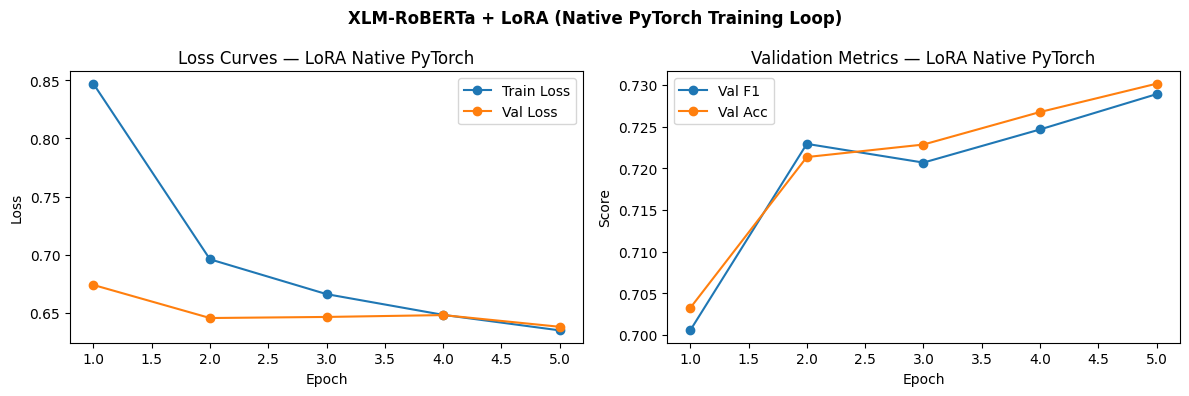

In [ ]:
# plot training curves

hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="Train Loss", marker="o")
axes[0].plot(hist_df["epoch"], hist_df["val_loss"],   label="Val Loss",   marker="o")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curves — LoRA Native PyTorch")
axes[0].legend()

axes[1].plot(hist_df["epoch"], hist_df["val_f1"],  label="Val F1",  marker="o")
axes[1].plot(hist_df["epoch"], hist_df["val_acc"], label="Val Acc", marker="o")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score")
axes[1].set_title("Validation Metrics — LoRA Native PyTorch")
axes[1].legend()

plt.suptitle("XLM-RoBERTa + LoRA (Native PyTorch Training Loop)", fontweight="bold")
plt.tight_layout()
plt.show()


── Synthetic Test Set ──────────────────────────
              precision    recall  f1-score   support

    Positive     0.7966    0.8176    0.8070      3334
    Negative     0.7491    0.7498    0.7494      3333
     Neutral     0.6320    0.6148    0.6233      3333

    accuracy                         0.7274     10000
   macro avg     0.7259    0.7274    0.7266     10000
weighted avg     0.7259    0.7274    0.7266     10000



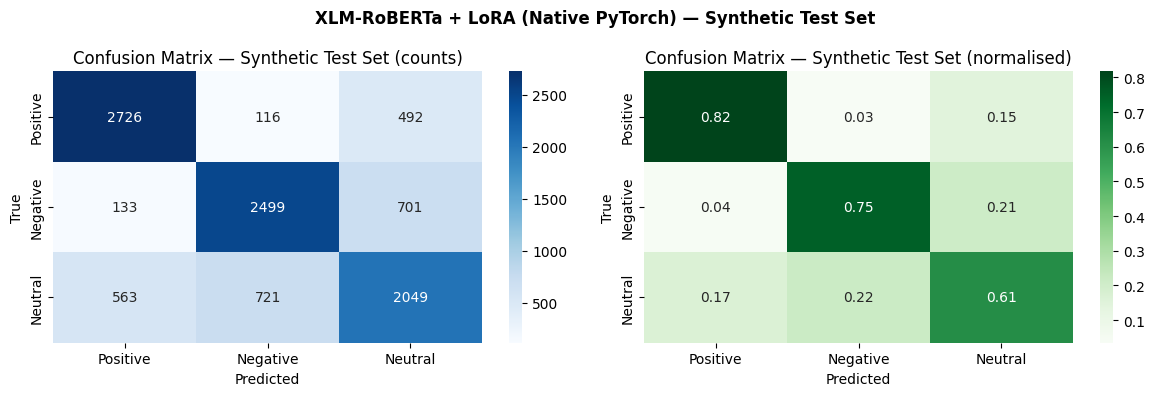


── SentMix-3L Natural Test Set ──────────────────────────
              precision    recall  f1-score   support

    Positive     0.6629    0.9738    0.7888       420
    Negative     0.8650    0.5807    0.6949       353
     Neutral     0.3399    0.2222    0.2687       234

    accuracy                         0.6614      1007
   macro avg     0.6226    0.5923    0.5842      1007
weighted avg     0.6587    0.6614    0.6350      1007



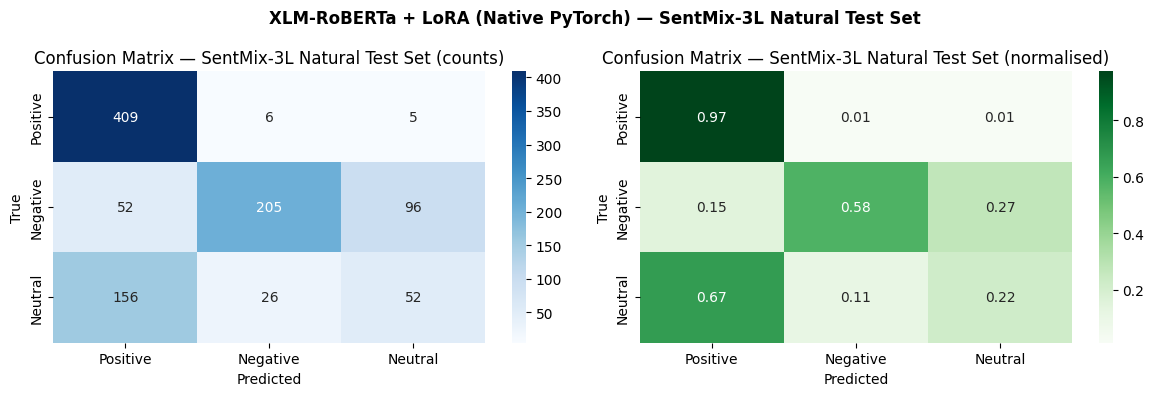

In [ ]:
# evaluation

def full_evaluate(loader, name):
    _, f1, acc, preds, labels = eval_epoch(model, loader)

    print(f"\n── {name} ──────────────────────────")
    print(classification_report(labels, preds,
          target_names=list(LABEL2ID.keys()), digits=4))

    report = classification_report(labels, preds,
             target_names=list(LABEL2ID.keys()),
             digits=4, output_dict=True)

    cm = confusion_matrix(labels, preds)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=list(LABEL2ID.keys()),
                yticklabels=list(LABEL2ID.keys()), ax=axes[0])
    axes[0].set_title(f"Confusion Matrix — {name} (counts)")
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens",
                xticklabels=list(LABEL2ID.keys()),
                yticklabels=list(LABEL2ID.keys()), ax=axes[1])
    axes[1].set_title(f"Confusion Matrix — {name} (normalised)")
    axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

    plt.suptitle(f"XLM-RoBERTa + LoRA (Native PyTorch) — {name}", fontweight="bold")
    plt.tight_layout()
    plt.show()

    return report

report_test = full_evaluate(test_loader,     "Synthetic Test Set")
report_nat  = full_evaluate(test_nat_loader, "SentMix-3L Natural Test Set")

In [ ]:
# results summary

wf1     = report_test["weighted avg"]["f1-score"]
mf1     = report_test["macro avg"]["f1-score"]
acc     = report_test["accuracy"]
wf1_nat = report_nat["weighted avg"]["f1-score"]
mf1_nat = report_nat["macro avg"]["f1-score"]
acc_nat = report_nat["accuracy"]

print("=" * 60)
print("  FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"  Model              : {CONFIG['model_name']}")
print(f"  Framework          : Native PyTorch (no Trainer API)")
print(f"  PEFT method        : LoRA from scratch")
print()
print("  ── Parameters ───────────────────────────────────────────")
print(f"  Total params       : {total_params:>12,}")
print(f"  Trainable (LoRA)   : {trainable_params:>12,}  ({pct:.3f}%)")
print(f"  Frozen (XLM-R)     : {total_params - trainable_params:>12,}")
print()
print("  ── Training ─────────────────────────────────────────────")
print(f"  Training time      : {elapsed:.1f}s  ({elapsed/60:.1f} min)")
print(f"  Epochs run         : {len(history)}")
print(f"  Batch size         : {CONFIG['batch_size']}")
print(f"  Learning rate      : {CONFIG['learning_rate']}")
print()
print("  ── Primary: Synthetic Test Set ──────────────────────────")
print(f"  Weighted F1        : {wf1:.4f}")
print(f"  Macro F1           : {mf1:.4f}")
print(f"  Accuracy           : {acc:.4f}")
print()
print("  ── Secondary: SentMix-3L Natural Test Set ───────────────")
print(f"  Weighted F1        : {wf1_nat:.4f}")
print(f"  Macro F1           : {mf1_nat:.4f}")
print(f"  Accuracy           : {acc_nat:.4f}")
print("=" * 60)

summary = {
    "model": CONFIG["model_name"],
    "framework": "Native PyTorch (no Trainer API)",
    "lora": {"r": CONFIG["lora_r"], "alpha": CONFIG["lora_alpha"],
             "dropout": CONFIG["lora_dropout"]},
    "params": {"total": total_params, "trainable": trainable_params,
               "frozen": total_params - trainable_params,
               "trainable_pct": round(pct, 4)},
    "training": {"epochs_run": len(history), "time_sec": round(elapsed, 2),
                 "lr": CONFIG["learning_rate"],
                 "batch_size": CONFIG["batch_size"]},
    "primary_test_synthetic": {
        "weighted_f1": round(wf1, 4),
        "macro_f1":    round(mf1, 4),
        "accuracy":    round(acc, 4),
    },
    "secondary_test_sentmix3l": {
        "weighted_f1": round(wf1_nat, 4),
        "macro_f1":    round(mf1_nat, 4),
        "accuracy":    round(acc_nat, 4),
    },
}
with open("pytorch_lora_native_results.json", "w") as f:
    json.dump(summary, f, indent=2)
print("\nSaved → pytorch_lora_native_results.json ✓")

  FINAL RESULTS SUMMARY
  Model              : xlm-roberta-base
  Framework          : Native PyTorch (no Trainer API)
  PEFT method        : LoRA from scratch

  ── Parameters ───────────────────────────────────────────
  Total params       :  278,340,867
  Trainable (LoRA)   :      887,811  (0.319%)
  Frozen (XLM-R)     :  277,453,056

  ── Training ─────────────────────────────────────────────
  Training time      : 4338.5s  (72.3 min)
  Epochs run         : 5
  Batch size         : 32
  Learning rate      : 0.0001

  ── Primary: Synthetic Test Set ──────────────────────────
  Weighted F1        : 0.7266
  Macro F1           : 0.7266
  Accuracy           : 0.7274

  ── Secondary: SentMix-3L Natural Test Set ───────────────
  Weighted F1        : 0.6350
  Macro F1           : 0.5842
  Accuracy           : 0.6614

Saved → pytorch_lora_native_results.json ✓


In [ ]:
# inference demo

import re, unicodedata

DEMO_SENTENCES = [
    ("আজকের দিনটা khub bhalo ছিল, I am so happy today!",         "Positive"),
    ("Aaj main bahut khush hoon কারণ আমার result ভালো হয়েছে!",  "Positive"),
    ("यह फिल्म একদম bakwas ছিল, worst movie I have ever seen.",   "Negative"),
    ("দিনটা বাজে গেছে, sab kuch galat ho gaya today.",             "Negative"),
    ("আবহাওয়া আজ theek hai, kuch khaas nahi.",                    "Neutral"),
    ("Main office গেছি, কাজ শেষ করলাম, ghar wapis aa gaya.",     "Neutral"),
]

def quick_clean(text):
    text = unicodedata.normalize("NFC", text)
    text = re.sub(r"https?://\S+|@\w+", " ", text)
    return re.sub(r"\s+", " ", text).strip()

model.eval()
print("─" * 70)
print(f"{'Input (truncated)':<44} {'True':>10} {'Pred':>10} {'Conf':>7}")
print("─" * 70)

for text, true_label in DEMO_SENTENCES:
    clean = quick_clean(text)
    enc   = tokenizer(clean, return_tensors="pt", truncation=True,
                      max_length=CONFIG["max_length"], padding=True)
    enc   = {k: v.to(device) for k, v in enc.items()}

    with torch.no_grad():
        logits = model(**enc).logits
    probs   = torch.softmax(logits, dim=-1)[0]
    pred_id = probs.argmax().item()
    conf    = probs.max().item()
    match   = "✓" if ID2LABEL[pred_id] == true_label else "✗"
    print(f"{match} {text[:42]:<42} {true_label:>10} {ID2LABEL[pred_id]:>10} {conf:>6.1%}")

print("─" * 70)

──────────────────────────────────────────────────────────────────────
Input (truncated)                                  True       Pred    Conf
──────────────────────────────────────────────────────────────────────
✗ আজকের দিনটা khub bhalo ছিল, I am so happy    Positive    Neutral  44.6%
✓ Aaj main bahut khush hoon কারণ আমার result   Positive   Positive  91.4%
✓ यह फिल्म একদম bakwas ছিল, worst movie I ha   Negative   Negative  98.0%
✗ দিনটা বাজে গেছে, sab kuch galat ho gaya to   Negative    Neutral  79.4%
✓ আবহাওয়া আজ theek hai, kuch khaas nahi.       Neutral    Neutral  78.3%
✗ Main office গেছি, কাজ শেষ করলাম, ghar wapi    Neutral   Negative  42.0%
──────────────────────────────────────────────────────────────────────


In [ ]:
# save model

SAVE_PATH = "/content/pytorch_lora_native_model"
os.makedirs(SAVE_PATH, exist_ok=True)
torch.save(model.state_dict(), f"{SAVE_PATH}/model_weights.pt")
tokenizer.save_pretrained(SAVE_PATH)

size_mb = sum(
    os.path.getsize(os.path.join(SAVE_PATH, f))
    for f in os.listdir(SAVE_PATH)
) / 1e6

print(f"Model saved : {SAVE_PATH}")
print(f"Model size  : {size_mb:.1f} MB")

Model saved : /content/pytorch_lora_native_model
Model size  : 1130.3 MB
